# 3장 실습 — 같은 모델을 세 번 쓴다

**PyTorch 판**

2장의 사과 분류를 이 판의 방식으로 씁니다.
**하는 일은 세 판이 완전히 같습니다.** 달라지는 것은 §3.2와 §3.3 두 셀뿐입니다.

세 판을 나란히 열어 놓고 읽어 보십시오.
무엇이 딥러닝이고 무엇이 이 라이브러리의 사정인지가 저절로 갈립니다.

## 3.0 준비

`dlbook.versions()` 가 출력하는 것은 **이미 불러온** 라이브러리뿐입니다.
쓰지도 않을 프레임워크를 버전 확인하겠다고 메모리에 올리지 않습니다.

In [1]:
# 아무것도 설치되어 있지 않은 브라우저 환경에서도 이 셀 하나면 준비가 끝난다.
# Kaggle · JupyterHub · Colab 어디서 열어도 같다. 개인 노트북에는 아무것도 설치하지 않는다.
try:
    import dlbook
except ImportError:
    !pip install -q "dlbook @ git+https://github.com/dhrim/deep-learning-in-one-semester.git"
    import dlbook

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import dlbook
from dlbook import data, metrics, plot

dlbook.set_seed(42)
plot.use_korean()
print(dlbook.versions())

{'python': '3.12.3', 'numpy': '2.1.3', 'keras': '-', 'tensorflow': '-', 'torch': '2.14.0', 'keras_backend': '-'}


## 3.1 데이터 — 세 판이 글자까지 같은 셀

`dlbook.data` 는 **numpy 배열**을 돌려줍니다. tf.Tensor도 torch.Tensor도
아닙니다. 그래서 이 셀이 세 판에서 같을 수 있습니다.

In [3]:
x, y = data.apples(n=400, seed=42)
s = data.split(x, y, val_ratio=0.2, test_ratio=0.2, seed=42)
print(s.summary())

구분            개수  입력 shape
train        240  (2,)
val           80  (2,)
test          80  (2,)


## 3.2 모델 정의 — 여기부터 판마다 다릅니다

만드는 것은 같습니다. **가중치 2개와 편향 1개.** 2장 〈그림 2-7〉의 그 구조입니다.

In [4]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

dlbook.set_seed(42)   # 프레임워크를 불러온 뒤 한 번 더

device = "cuda" if torch.cuda.is_available() else "cpu"

model = nn.Sequential(nn.Linear(2, 1)).to(device)   # 가중치 2개 + 편향 1개
criterion = nn.BCEWithLogitsLoss()                  # 안쪽에서 sigmoid까지 한다
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
print(model, "/ device:", device)

Sequential(
  (0): Linear(in_features=2, out_features=1, bias=True)
) / device: cpu


## 3.3 학습 — 여기도 판마다 다릅니다

무엇을 하는지 보십시오. 이름만 다르고 하는 일이 같습니다.

1. 예측한다
2. 정답과 견주어 손실을 구한다
3. **경사를 구한다** (2장 §2.11의 자동 미분)
4. **그 방향으로 가중치를 옮긴다** (2장 §2.10의 경사하강)

In [5]:
def as_ds(xa, ya):
    return TensorDataset(torch.tensor(xa, dtype=torch.float32),
                         torch.tensor(ya, dtype=torch.float32).view(-1, 1))

train_dl = DataLoader(as_ds(s.x_train, s.y_train), batch_size=16, shuffle=True)
xv = torch.tensor(s.x_val, dtype=torch.float32).to(device)
yv = torch.tensor(s.y_val, dtype=torch.float32).view(-1, 1).to(device)

history = {"loss": [], "val_loss": []}
for _ in range(dlbook.smoke.epochs(60)):
    model.train()
    losses = []
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()                       # 지난번 경사를 지우고
        loss = criterion(model(xb), yb)             # ② 손실
        loss.backward()                             # ③ 경사를 구하고
        optimizer.step()                            # ④ 그 방향으로 내려간다
        losses.append(loss.item())
    model.eval()
    with torch.no_grad():
        history["val_loss"].append(criterion(model(xv), yv).item())
    history["loss"].append(float(np.mean(losses)))

def fw_predict(g):
    model.eval()
    with torch.no_grad():
        logit = model(torch.tensor(np.asarray(g), dtype=torch.float32).to(device))
    return (logit.cpu().numpy().reshape(-1) > 0).astype("int64")

## 3.4 결과 — 세 판이 같은 숫자를 냅니다

같은 데이터, 같은 구조, 같은 학습률, 같은 epoch입니다.
그러니 같은 답이 나오는 것이 당연합니다.

ch03_apple_test_acc = 0.9500


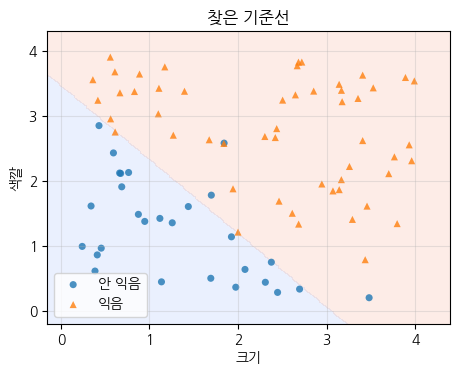

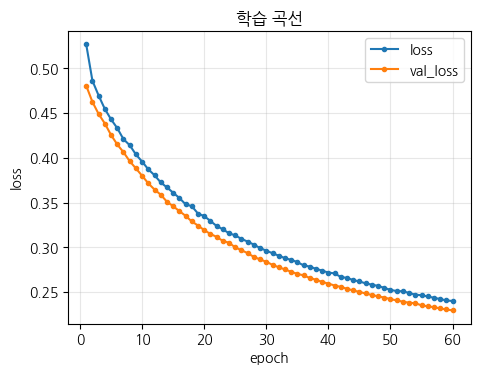

In [6]:
acc = metrics.accuracy(s.y_test, fw_predict(s.x_test))
dlbook.record("ch03_apple_test_acc", acc)

plot.decision_boundary(fw_predict, s.x_test, s.y_test, title="찾은 기준선")
plt.show()

plot.loss_curve(history)
plt.show()

## 정리

- 세 판에서 **다른 셀은 §3.2와 §3.3 둘뿐**입니다. 나머지는 글자까지 같습니다.
- 그 둘은 **모델을 정의하는 셀**과 **학습 루프 셀**입니다.
- Keras의 `fit()` 안에서 TensorFlow·PyTorch 판이 손으로 쓴 그 네 줄이 돌고 있습니다.
- **프레임워크를 바꾸면 코드의 생김새가 바뀝니다. 딥러닝이 바뀌지는 않습니다.**

### 연습

1. 세 판을 나란히 열고 **다른 셀이 몇 개인지** 직접 세어 보십시오.
2. 이 노트북의 모델에 은닉층을 하나 넣어 보십시오. 세 판에서 각각 몇 줄이 바뀝니까.
3. PyTorch 판에서 `optimizer.zero_grad()` 를 주석 처리하면 어떻게 됩니까.